# An introduction to graph theory

Now it is time to move on to the basics of graph theory, their implementations and applications.

## Exercise 1.

Create an adjacency matrix to the following graph:

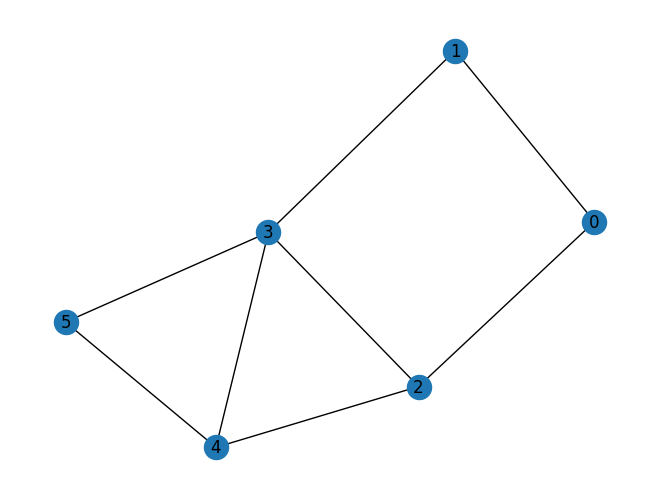

In [1]:
# nodes: a=0, b=1, c=2, d=3, e=4 ,f=5
a, b, c, d, e, f = range(6)

adjacency_matrix = [
    # a  b  c  d  e  f
    [0, 1, 1, 0, 0, 0], # a
    [1, 0, 0, 1, 0, 0], # b
    [1, 0, 0, 1, 1, 0], # c
    [0, 1, 1, 0, 1, 1], # d
    [0, 0, 1, 1, 0, 1], # e
    [0, 0, 0, 1, 1, 0]  # f
]

# Check out the connections
def check_connection(node1, node2):
    print(f"Connection between {node1} and {node2}: {adjacency_matrix[node1][node2] == 1}") 

check_connection(a, b)


Connection between 0 and 1: True


## Exercise 2.

Create a adjacency list representation for the graph below:

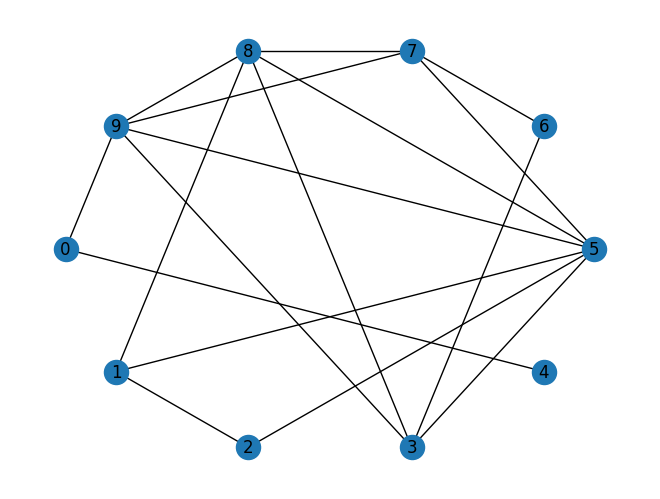

In [ ]:
# nodes a=0, b=1, c=2, d=3, e=4, f=5, g=6, h=7, i=8, j=9
a, b, c, d, e, f, g, h, i, j = range(10)

adjacency_list = [
    [e, j],             # a (0)
    [c, f, i],          # b (1)
    [b, f],             # c (2) 
    [f, g, i, j],       # d (3)
    [a],                # e (4)
    [b, c, d, h, i, j], # f (5)
    [d, h],             # g (6)
    [f, g, j],          # h (7)
    [b, d, f],          # i (8)
    [a, d, f, h, i]     # j (9)
]

def check_connection(node1, node2):
    print(f"Connection between {node1} and {node2}: {node2 in adjacency_list[node1]}")

check_connection(a, a)

Connection between 0 and 0: False


## Exercise 3.

Create a function which checks whether two points are adjacent in a graph. Your function should take four arguments -- the graph structure, edge ends and a keyword argument `representation` which takes the default value `matrix` but can be switched to `lists`. As you might have already guessed, the last argument determines the method of interpretation of the structure.

In [3]:
def check_adjacency(graph, node1, node2, representation = 'matrix'):
    '''
    Function checks whether two points `node1` and `node2` are adjacent in a given `graph`.

    Args:
        graph: The graph with all the edges, it can be adjacency matrix or adjacency list.
        representation (string): Default is set to `matrix`, but it can be switched to `lists`. If you input adjacency list switch this option.

    Returns:
        Adjacency: `True` or `False`.
    '''
    
    # Some default checking
    if graph is None or node1 is None or node2 is None:
        print('Error: Missing values.')
        return False
    if representation not in ['matrix', 'lists']:
        print('Error: Unknown representation.')
        return False
    
    # Check for matrix
    if representation == 'matrix':
        try: 
            return graph[node1][node2] != 0
        except IndexError:
            print("Error: Node index out of range for graph size.")
            return False
    
    # Check for lists
    if representation == 'lists':
        try: 
            return node2 in graph[node1]
        except (IndexError, KeyError):
            print("Error: Node not found in adjacency list.")
            return False

print(check_adjacency(adjacency_matrix, a, c))
    

True


# Exercise 4.

Create a function which determines if a given sequence of vertices forms a path. Your function should take two arguments -- graph representation, sequence (in a form of a tuple or list) and keyword for the method of representation.

In [ ]:
a, b, c, d, e, f, g, h, i, j = range(10)

adjacency_list = [
    [e, j],             # a (0)
    [c, f, i],          # b (1)
    [b, f],             # c (2) 
    [f, g, i, j],       # d (3)
    [a],                # e (4)
    [b, c, d, h, i, j], # f (5)
    [d, h],             # g (6)
    [f, g, j],          # h (7)
    [b, d, f],          # i (8)
    [a, d, f, h, i]     # j (9)
]

adjacency_matrix = [
    # a  b  c  d  e  f
    [0, 1, 1, 0, 0, 0], # a
    [1, 0, 0, 1, 0, 0], # b
    [1, 0, 0, 1, 1, 0], # c
    [0, 1, 1, 0, 1, 1], # d
    [0, 0, 1, 1, 0, 1], # e
    [0, 0, 0, 1, 1, 0]  # f
]

sequence = (a, b, d, f, b)

def check_the_path(graph, seq, representation='matrix'):

    # 1. Some default checking
    if graph is None or seq is None:
        print('Error: Missing values.')
        return False
    if representation not in ['matrix', 'lists']:
        print('Error: Unknown representation.')
        return False

    # The path of lenght 0 or 1 is always a path
    if len(seq) <= 1:
        return True

    if representation == 'lists':
        for i in range(len(seq)):
            if i == len(seq) - 1:
                return True
            if seq[i + 1] not in graph[seq[i]]:
                return False
    elif representation == 'matrix':
        for i in range(len(seq)):
            if i == len(seq) - 1:
                return True
            if graph[seq[i]][seq[i + 1]] == 0:
                return False
    

print(check_the_path(adjacency_matrix, sequence))

False


# Exercise 5.

Modify the code from the first two exercises to store the following directed graph.
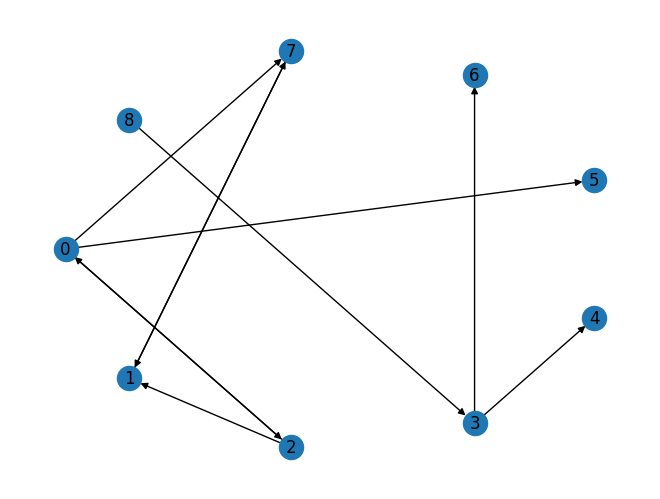

In [1]:
# Here we have the nodes a=0, b=1, c=2, d=3, e=4, f=5, g=6, h=7 i=8
a, b, c, d, e, f, g, h, i = range(9)

directed_adjacency_list = [
    [c, f, h],      # a
    [h],            # b
    [a, b],         # c
    [e, g],         # d
    [],             # e
    [],             # f
    [],             # g
    [b],            # h
    [d]             # i
]

directed_adjacency_matrix = [
    #a  b  c  d  e  f  g  h  i
    [0, 0, 1, 0, 0, 1, 0, 1, 0], # a (0)
    [0, 0, 0, 0, 0, 0, 0, 1, 0], # b (1)
    [1, 1, 0, 0, 0, 0, 0, 0, 0], # c (2)
    [0, 0, 0, 0, 1, 0, 1, 0, 0], # d (3)
    [0, 0, 0, 0, 0, 0, 0, 0, 0], # e (4)
    [0, 0, 0, 0, 0, 0, 0, 0, 0], # f (5)
    [0, 0, 0, 0, 0, 0, 0, 0, 0], # g (6)
    [0, 1, 0, 0, 0, 0, 0, 0, 0], # h (7)
    [0, 0, 0, 1, 0, 0, 0, 0, 0]  # i (8)
]

# Exercise 6.

Use Depth-First Search or Breadth-First Search to create a function which checks whether there exists a path in the given directed graph from the vertex `i` to vertex `j`. Harder version -- enable user to use either graph representation via adjacency matrix or adjacency list.

In [2]:
# Here we have the nodes a=0, b=1, c=2, d=3, e=4, f=5, g=6, h=7 i=8
a, b, c, d, e, f, g, h, i = range(9)

directed_adjacency_list = [
    [c, f, h],      # a
    [h],            # b
    [a, b],         # c
    [e, g],         # d
    [],             # e
    [],             # f
    [],             # g
    [b],            # h
    [d]             # i
]

from collections import deque

def bfs_path_checking(graph, vertex_i, vertex_j):
    queue = deque([vertex_i])
    visited_nodes = {vertex_i}
    order_of_visiting = [vertex_i]

    if vertex_i == vertex_j:
        return True

    while queue:
        node = queue.popleft()

        for neighbour in graph[node]:
            if neighbour not in visited_nodes:
                visited_nodes.add(neighbour)
                order_of_visiting.append(neighbour)

                if neighbour == vertex_j:
                    print(order_of_visiting)
                    return True
                
                queue.append(neighbour)

    return False
        

bfs_path_checking(directed_adjacency_list, a, b)

[0, 2, 5, 7, 1]


True

In [ ]:
# Kod na zajęciach z prowadzącym

from collections import deque

def BFS(graph_structure, i, j):
    visited = {i}
    queue = deque([])
    queue.extend(graph_structure[i])
    while queue:
        current_vertex = queue.popleft()
        if current_vertex == j:
            return True
        else: 
            for neighbour in graph_structure[current_vertex]:
                if neighbour not in queue and neighbour not in visited:
                    queue.append(neighbour)